# ENGR-E 221 Homework 4: Linear Regression Models

In [1]:
#import the required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#import the csv file, using the , separator
my_dataset = pd.read_csv("/Users/zeynepamac/Desktop/E221/hw4/Electricity_Consumption.csv", sep=",")
my_dataset.shape

my_dataset.head()

,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620


# **Data Preprocessing (10 points)**

In [2]:
#counts the total number of duplicate rows in the data frame
print("Duplicated rows:", my_dataset.duplicated().sum())


#will loop for each column in the column list and if there is a missing value, it will print it
for column in my_dataset.columns:
    if my_dataset[column].isnull().sum() != 0:
        print(f"{column} -> Missing Values : {my_dataset[column].isnull().sum()}, dtypes : {my_dataset[column].dtypes}")



Duplicated rows: 0


In [3]:
# check for categorical columns
categorical_columns = my_dataset.select_dtypes(include="object").columns

print("Categorical columns:", categorical_columns.tolist())

Categorical columns: ['DateTime']


In [4]:
#convert date label to actual date
my_dataset["DateTime"] = pd.to_datetime(my_dataset["DateTime"])
print(my_dataset["DateTime"].dtype)

# convert useful numerical features from datetime
my_dataset["Hour"] = my_dataset["DateTime"].dt.hour
my_dataset["Month"] = my_dataset["DateTime"].dt.month
my_dataset["DayOfWeek"] = my_dataset["DateTime"].dt.dayofweek

my_dataset.head()

datetime64[ns]


,DateTime,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption,Hour,Month,DayOfWeek
0,2017-01-01 00:00:00,6.559,73.8,0.083,0.051,0.119,34055.69620,0,1,6
1,2017-01-01 00:10:00,6.414,74.5,0.083,0.070,0.085,29814.68354,0,1,6
2,2017-01-01 00:20:00,6.313,74.5,0.080,0.062,0.100,29128.10127,0,1,6
3,2017-01-01 00:30:00,6.121,75.0,0.083,0.091,0.096,28228.86076,0,1,6
4,2017-01-01 00:40:00,5.921,75.7,0.081,0.048,0.085,27335.69620,0,1,6


In [5]:
my_dataset = my_dataset.drop(columns=["DateTime"]) #remove datetime because it's unnecessary

# **Multicollinearity Analysis (8 points)**

,Temperature,Humidity,Wind Speed,general diffuse flows,diffuse flows,Power Consumption,Hour,Month,DayOfWeek
Temperature,1.000000,-0.460243,0.477109,0.460294,0.196522,0.440221,1.971305e-01,2.843350e-01,-1.370995e-02
Humidity,-0.460243,1.000000,-0.135853,-0.468138,-0.256886,-0.287421,-2.426916e-01,-1.741931e-02,-1.711388e-02
Wind Speed,0.477109,-0.135853,1.000000,0.133733,-0.000972,0.167444,4.148645e-03,1.683554e-01,3.211641e-02
general diffuse flows,0.460294,-0.468138,0.133733,1.000000,0.564718,0.187965,1.299766e-01,-2.055450e-02,9.666328e-03
diffuse flows,0.196522,-0.256886,-0.000972,0.564718,1.000000,0.080274,1.309090e-01,-1.297793e-01,-2.453960e-02
Power Consumption,0.440221,-0.287421,0.167444,0.187965,0.080274,1.000000,7.279525e-01,-5.346049e-03,-6.970813e-02
Hour,0.197130,-0.242692,0.004149,0.129977,0.130909,0.727953,1.000000e+00,-5.926402e-16,-5.389503e-17
Month,0.284335,-0.017419,0.168355,-0.020554,-0.129779,-0.005346,-5.926402e-16,1.000000e+00,6.387829e-03
DayOfWeek,-0.013710,-0.017114,0.032116,0.009666,-0.024540,-0.069708,-5.389503e-17,6.387829e-03,1.000000e+00


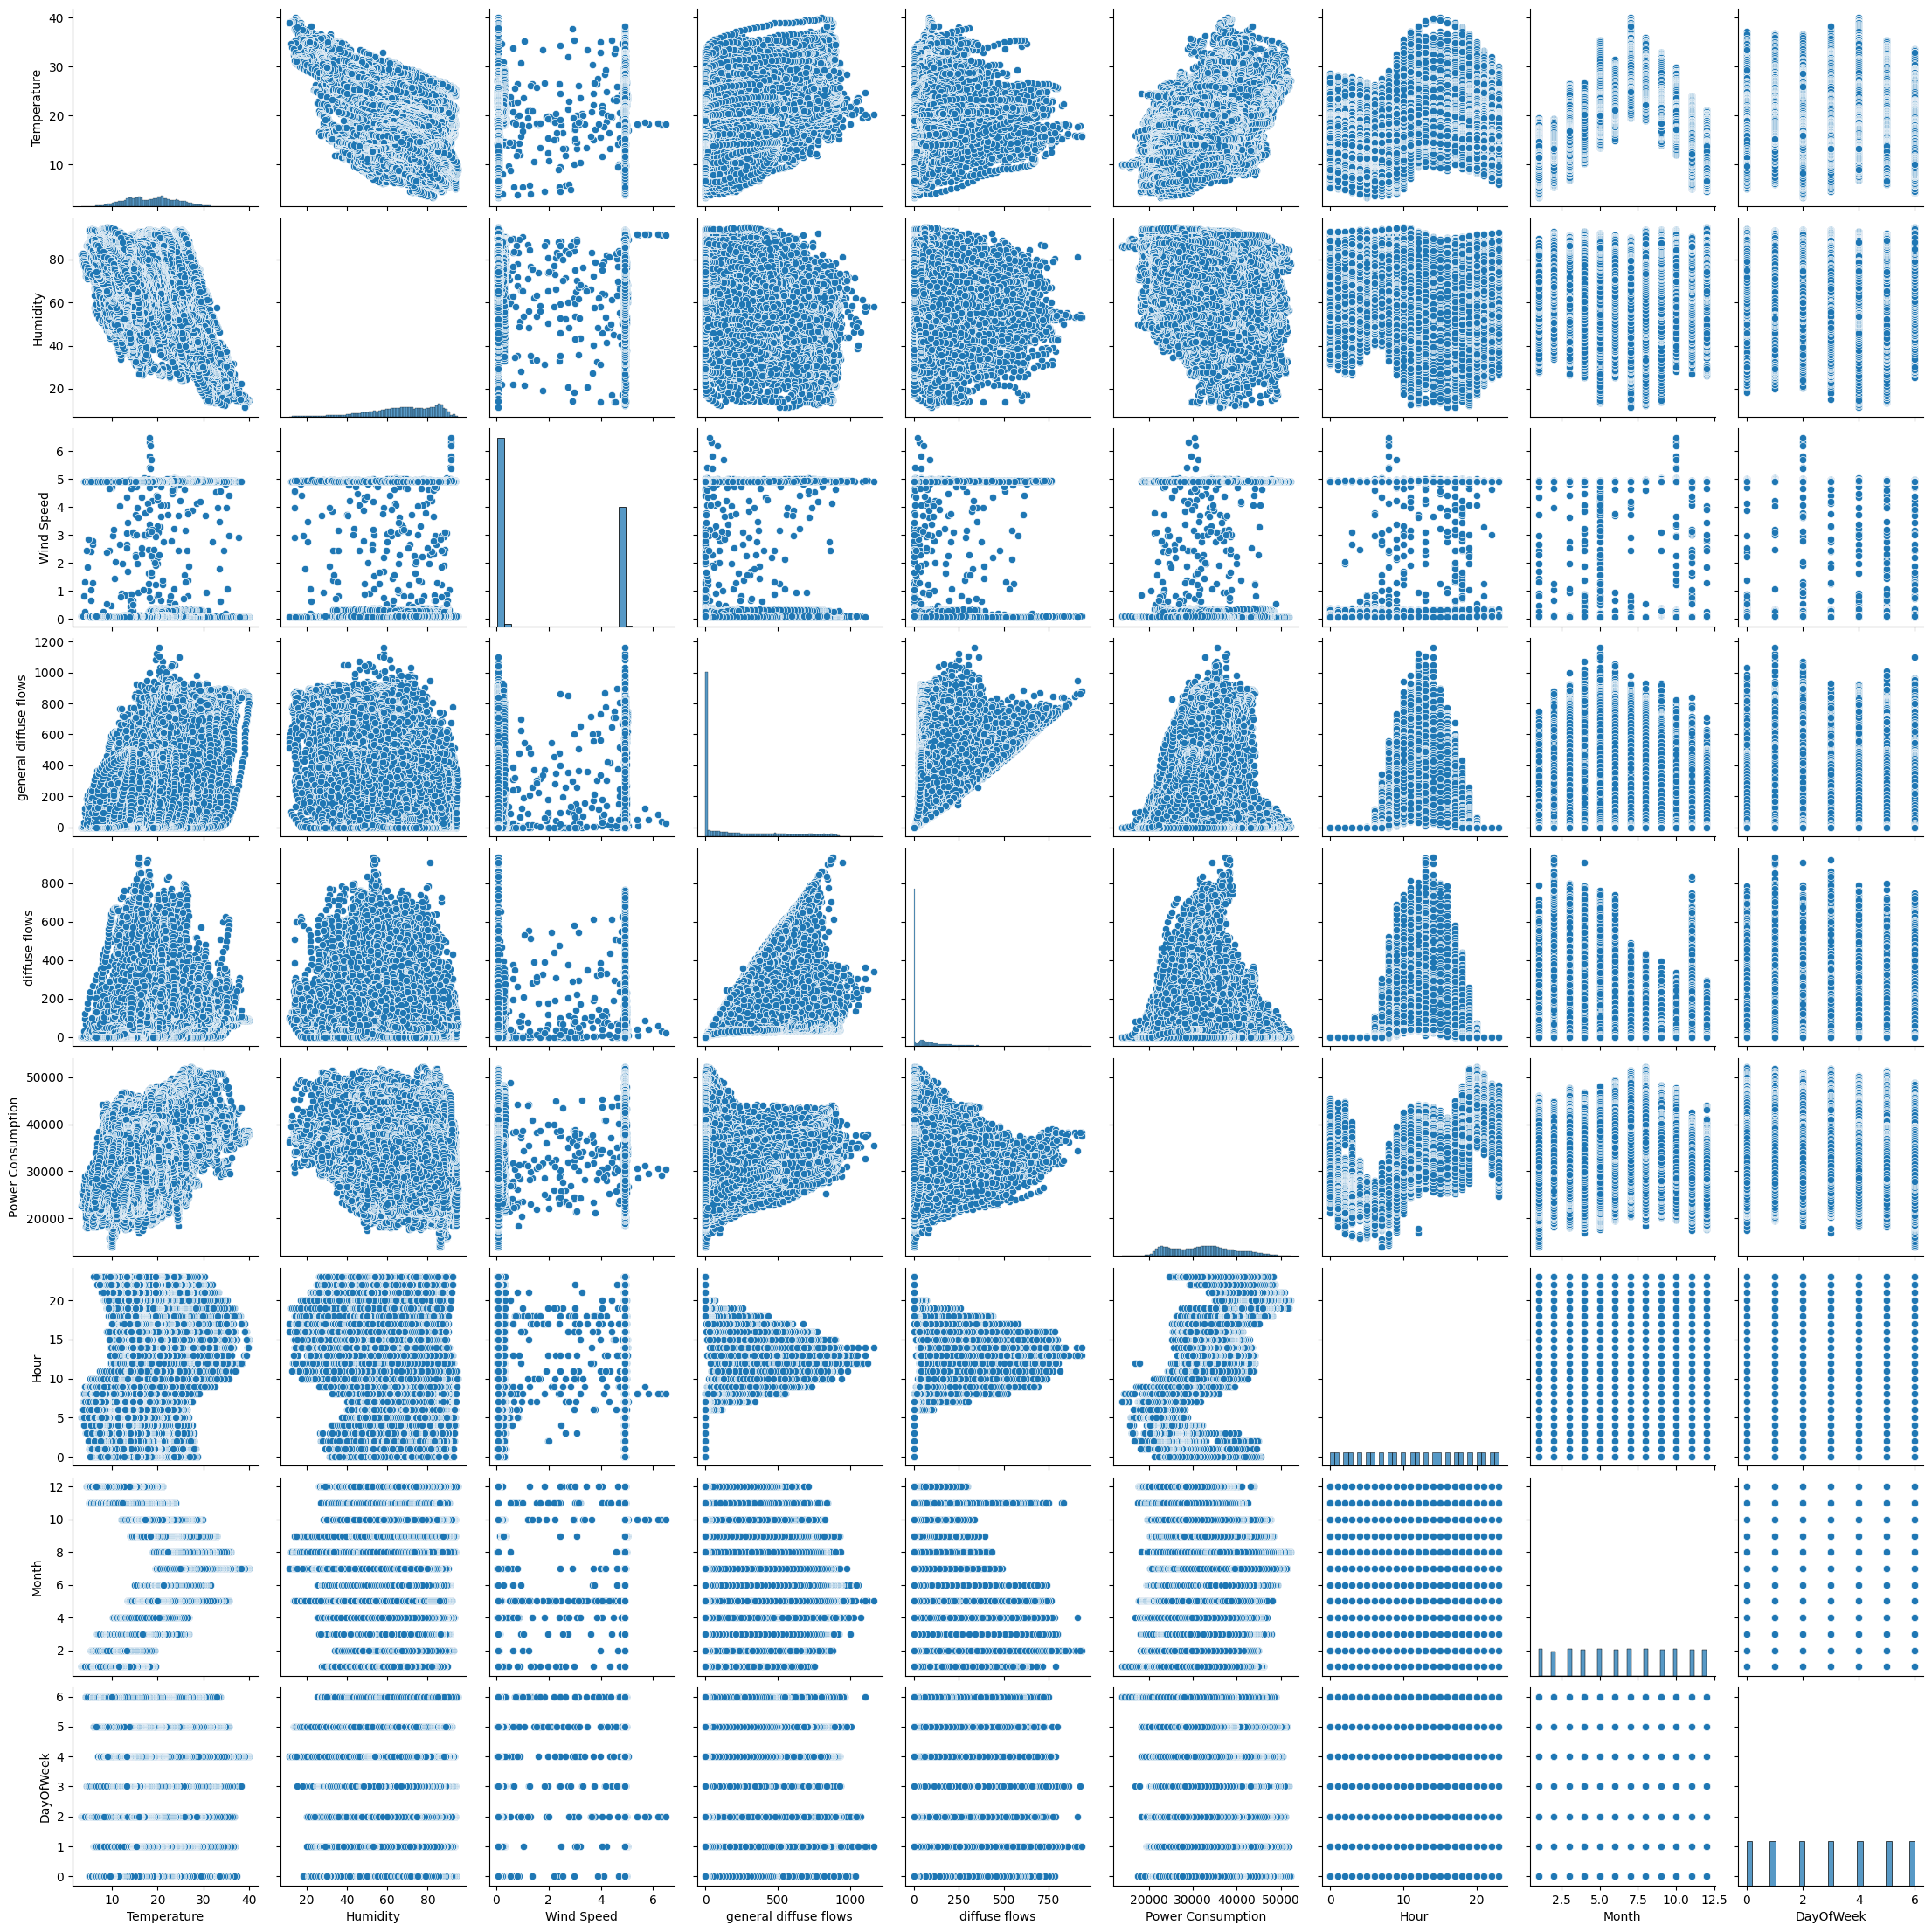

In [6]:
import seaborn as sb
sb.pairplot(my_dataset) # plot pairwise relationship between variables

# apply pearson

pearson_corr = my_dataset.corr(method="pearson")

pearson_corr



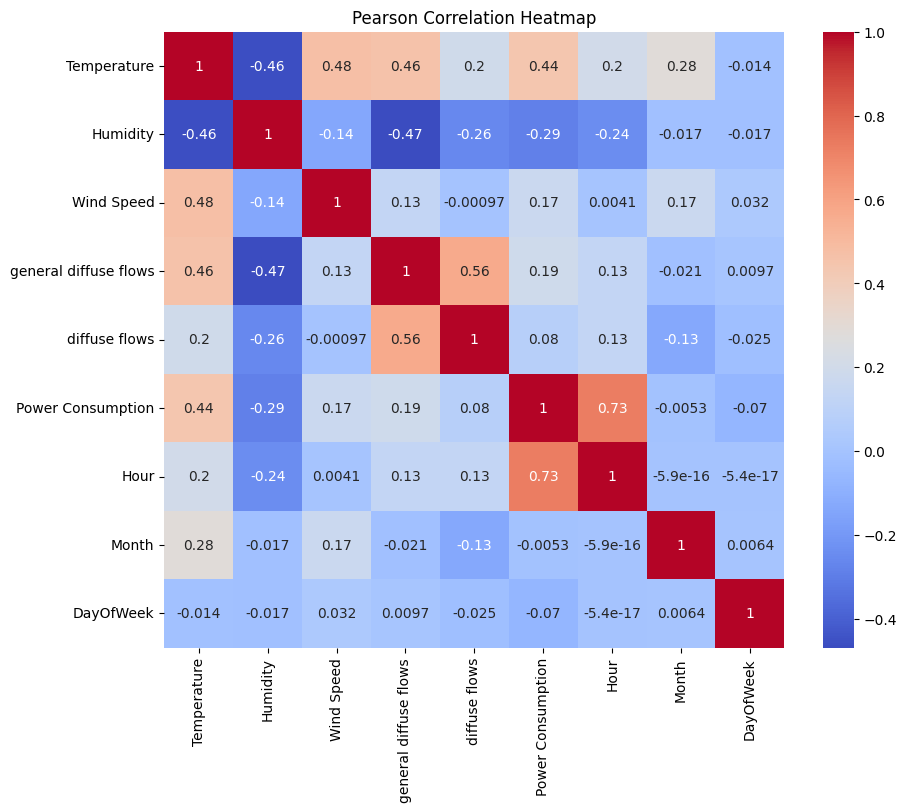

In [7]:
#plot the pearson results

plt.figure(figsize=(10, 8))

sb.heatmap(pearson_corr, annot=True, cmap="coolwarm")

plt.title("Pearson Correlation Heatmap")
plt.show()

Analysis: I used Pearson correlation and heatmap to see the relationship of the values. For example, power consumption vs hour have a strong correlation. Because its value is closer to 1, which is 0.73. Most variables showed weak or moderate correlations with each other.

# **Simple Linear Regression (8 points)**

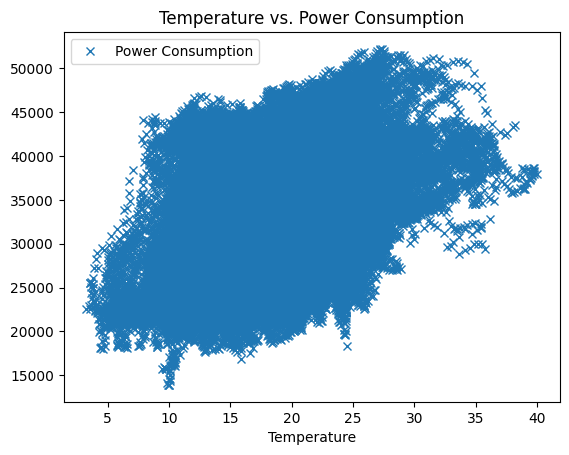

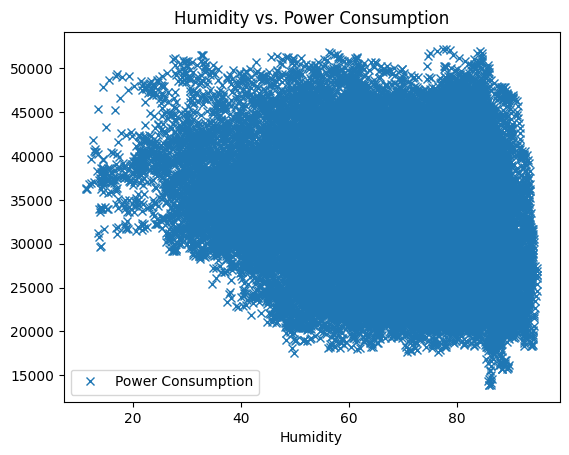

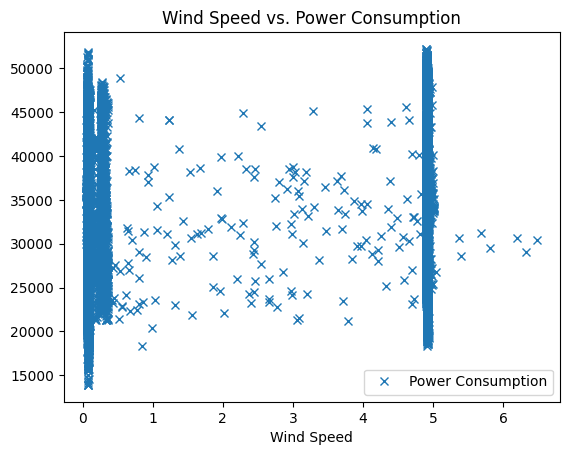

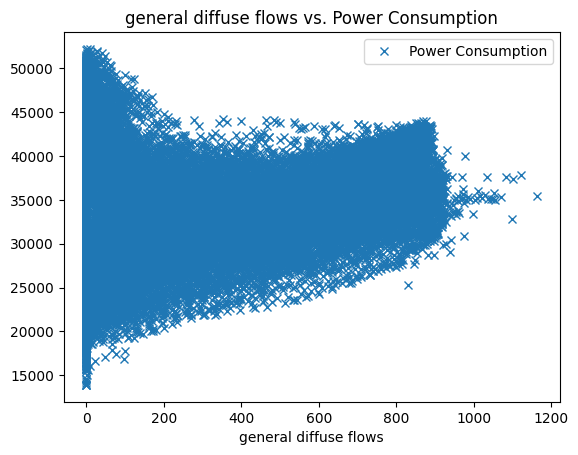

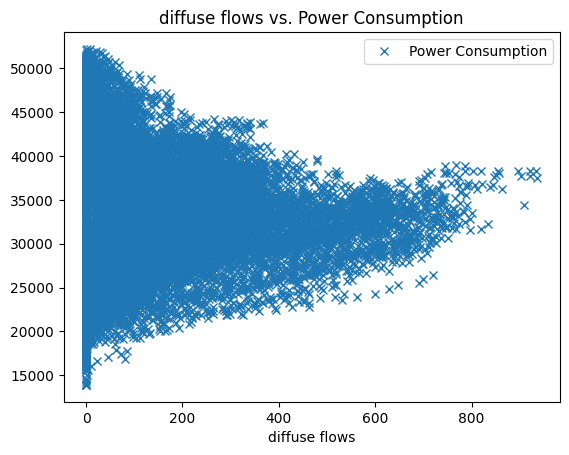

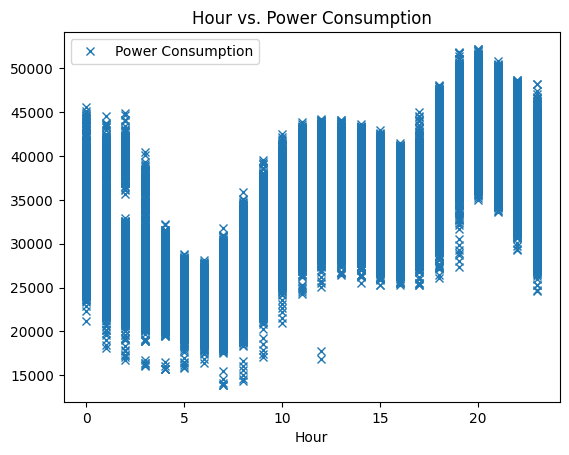

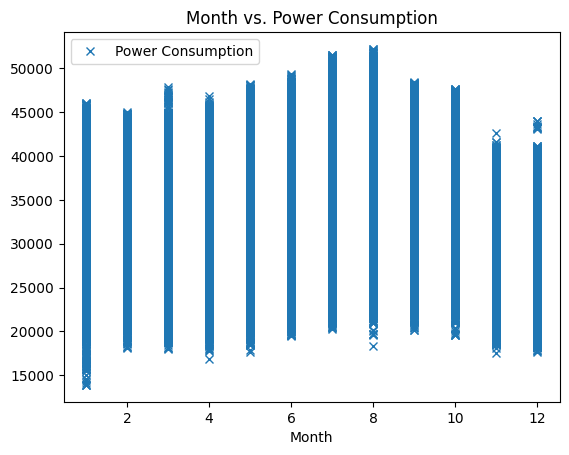

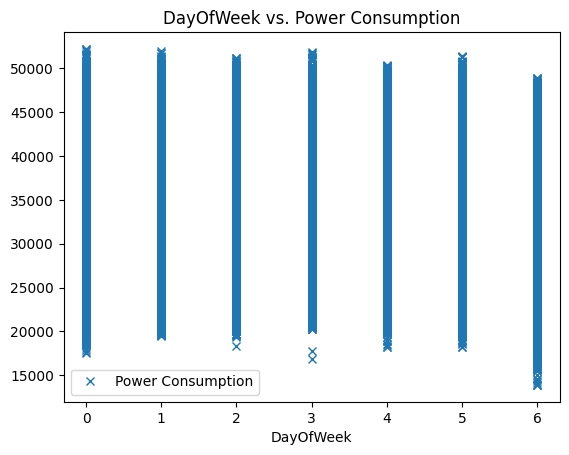

In [8]:
# import necessary libraries

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.metrics import r2_score


split = 0.2 #set a value to split

x = my_dataset[["Hour"]]

y = my_dataset["Power Consumption"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=split, random_state=0)

feature_columns = my_dataset.columns.drop("Power Consumption") #drop the target column

for feature in feature_columns: #loop through each column and then create columns against "Power Consumption"
    my_dataset.plot(x=feature,y="Power Consumption", style="x",title=f"{feature} vs. Power Consumption")



In [9]:
# temperature and power consumption
from sklearn.linear_model import LinearRegression


# build and train the linear regression model
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[750.32]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Hour']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.37e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [10]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (41932, 1)
y_train shape: (41932,)
x_test shape: (10484, 1)
y_test shape: (10484,)


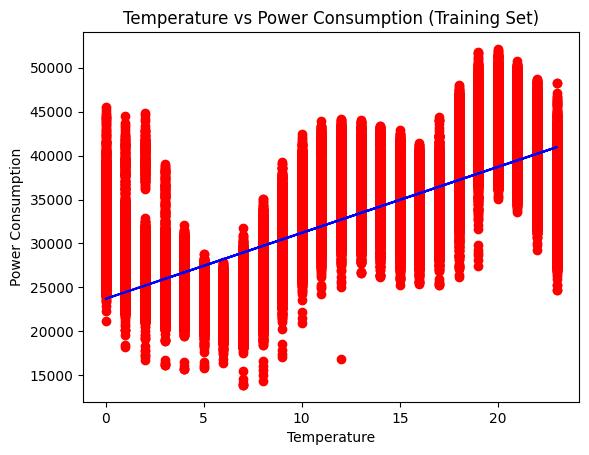

In [11]:
#get predicted probabilities
# Assuming y_test are actual values and y_pred are your predictions

import matplotlib.pyplot as plt


# Predict power consumption
y_pred = lin_reg.predict(x_test)

# Plot actual training data
plt.scatter(x_train, y_train, color="red")

# Plot regression line
plt.plot(x_train, lin_reg.predict(x_train), color="blue")

plt.title("Temperature vs Power Consumption (Training Set)")
plt.xlabel("Temperature")
plt.ylabel("Power Consumption")

plt.show()


In [12]:
# display the score Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error 

print("Simple Linear Regression")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Simple Linear Regression
R²: 0.5285105383297295
MAE: 3910.545127320364
RMSE: 4913.399474136153


# **Polynomial Regression (8 points)**

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# create polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)

x_train_poly = poly_features.fit_transform(x_train)
x_test_poly = poly_features.transform(x_test)

# fit the polynomial regression model
poly_reg = LinearRegression()
poly_reg.fit(x_train_poly, y_train)

# predict the test data
y_pred = poly_reg.predict(x_test_poly)

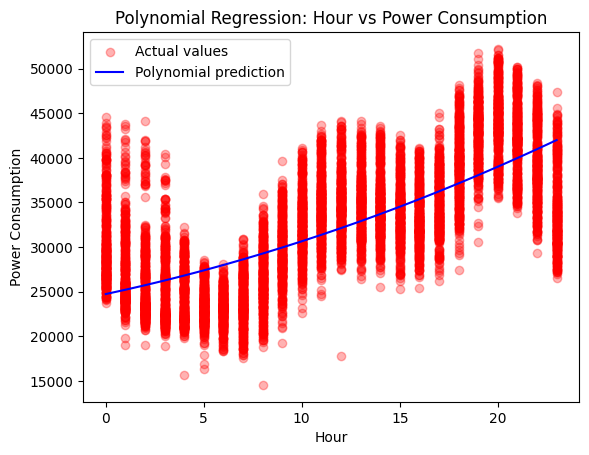

In [14]:
# plot polynomial regression
x_plot = x_test["Hour"].to_numpy()
order = np.argsort(x_plot)

plt.scatter(x_plot, y_test, color="red", alpha=0.3, label="Actual values")
plt.plot(x_plot[order], y_pred[order], color="blue", label="Polynomial prediction")

plt.title("Polynomial Regression: Hour vs Power Consumption")
plt.xlabel("Hour")
plt.ylabel("Power Consumption")
plt.legend()
plt.show()

In [15]:
# display the score for the comparison

print("Polynomial Regression")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Polynomial Regression
R²: 0.5338479003210193
MAE: 3885.5440734633853
RMSE: 4885.509951873252


# **Multiple Linear Regression (8 points)**

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Multiple predictor variables
x = my_dataset.drop(columns=["Power Consumption"])

# Target
y = my_dataset["Power Consumption"]

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=0
)

# Create and train model
regressor = LinearRegression()
regressor.fit(x_train, y_train)

# Make predictions
y_pred = regressor.predict(x_test)

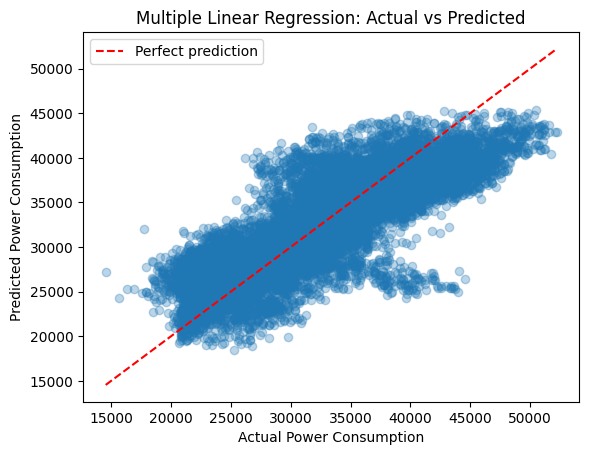

In [17]:
#plot for multiple linear regression

plt.scatter(y_test, y_pred, alpha=0.3)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Power Consumption")
plt.ylabel("Predicted Power Consumption")
plt.legend()
plt.show()


In [18]:
# display the score for the comparison

print("Multiple Linear Regression")
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Multiple Linear Regression
R²: 0.6506046420009601
MAE: 3354.475751568229
RMSE: 4229.652083428916


# **Model Comparison in Your Own Words (8 points)**

In [19]:
'''
Simple Linear Regression
R²: 0.5285105383297295
MAE: 3910.545127320364
RMSE: 4913.399474136153


Polynomial Regression
R²: 0.5338479003210193
MAE: 3885.5440734633853
RMSE: 4885.509951873252


Multiple Linear Regression
R²: 0.6506046420009601
MAE: 3354.475751568229
RMSE: 4229.652083428916

'''

'\nSimple Linear Regression\nR²: 0.5285105383297295\nMAE: 3910.545127320364\nRMSE: 4913.399474136153\n\n\nPolynomial Regression\nR²: 0.6506046420009601\nMAE: 3354.475751568229\nRMSE: 4229.652083428916\n\n\nMultiple Linear Regression\nR²: 0.6506046420009601\nMAE: 3354.475751568229\nRMSE: 4229.652083428916\n\n'

According to the overall comparison between the regression models, I think Multiple linear Regression is the best since the MAE score is higher and the R^2 is lower than the other scores. This means that using multiple predictor variables explains power consumption much better than using temperature alone. 

Polynomial regression performed only slightly better than simple sinear regression but the difference was huge. 

Overall, multiple linear regression makes more sense in this case.

Resources I've used:
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- https://sawtoothsoftware.com/resources/blog/posts/addressing-multicollinearity
- https://scikit-learn.org/stable/modules/model_evaluation.html
- https://stackoverflow.com/questions/45627784/unable-to-obtain-accuracy-score-for-my-linear-regression
- https://www.geeksforgeeks.org/machine-learning/multicollinearity-in-regression-analysis/
- https://medium.com/analytics-vidhya/mae-mse-rmse-coefficient-of-determination-adjusted-r-squared-which-metric-is-better-cd0326a5697e
